# Week 4 — Systems, Convolution, Difference Equations, and the z-Domain

**Story question:** Which processing steps can we reorder, how does a streaming algorithm remember the past, and why do some feedback systems become unstable?

**Flow:** system → linear and time-invariant → impulse response → convolution → correlation → recurrence → z^-1 → H(z) → poles → stability failure.

In [ ]:
# !uv pip install numpy matplotlib scipy scikit-learn 

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def time_axis(fs, duration):
    T = 1/fs
    t = np.arange(0, duration, T)
    return t

def generate_sine(f, t, A=1, p=0):
    y = A * np.sin(2 * np.pi * f * t + p)
    return y

def gain(x, a):
    return a* np.array(x)
    
def zscore(x):
    return (x - np.mean(x)) / np.std(x)

def moving_average(x, w):
    kernel = np.ones(w)/w
    y = np.convolve(x, kernel, mode='valid')
    return y


Text(0, 0.5, 'y')

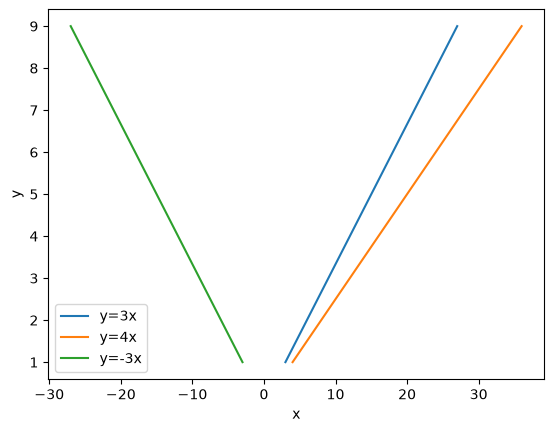

In [3]:
x = np.arange(1, 10)
plt.plot(3*x, x)
plt.plot(4*x, x)
plt.plot(-3*x, x)

plt.legend(['y=3x', 'y=4x', 'y=-3x'])
plt.xlabel('x')
plt.ylabel('y')

In [4]:
# Exercise 1
data = [1, 2, 3, 3, 2, 3, 3, 2, 1]

# Gain -> Moving avg
out1 = gain(data, 2)
out1 = moving_average(out1, 3)
print(out1)
# Moving avg -> Gain
out1 = moving_average(data, 3)
out1 = gain(out1, 2)
print(out1)


[4.         5.33333333 5.33333333 5.33333333 5.33333333 5.33333333
 4.        ]
[4.         5.33333333 5.33333333 5.33333333 5.33333333 5.33333333
 4.        ]


In [5]:
from scipy.signal import savgol_filter
# Gain -> sg-filter
out1 = gain(data, 2)
out1 = savgol_filter(out1, window_length = 3, polyorder=2)
print(out1)

# sg-filter -> Gain
out2 = savgol_filter(data, window_length = 3, polyorder = 2)
out2 = gain(out2, 2)
print(out2)



[2. 4. 6. 6. 4. 6. 6. 4. 2.]
[2. 4. 6. 6. 4. 6. 6. 4. 2.]


In [6]:
# Gain -> z-score
out3 = gain(data, 2)
out3 = zscore(out3)
print(out3)

# z-score -> Gain
out3 = zscore(data)
out3 = gain(out3, 2)
print(out3)


[-1.55563492 -0.28284271  0.98994949  0.98994949 -0.28284271  0.98994949
  0.98994949 -0.28284271 -1.55563492]
[-3.11126984 -0.56568542  1.97989899  1.97989899 -0.56568542  1.97989899
  1.97989899 -0.56568542 -3.11126984]


In [7]:
# z-score -> Moving avg
out4 = zscore(data)
out4 = moving_average(out4, 3)
print(out4)

# Moving avg -> z-score
out4 = moving_average(data, 3)
out4 = zscore(out4)
print(out4)


[-0.28284271  0.56568542  0.56568542  0.56568542  0.56568542  0.56568542
 -0.28284271]
[-1.58113883  0.63245553  0.63245553  0.63245553  0.63245553  0.63245553
 -1.58113883]


In [8]:
# z-score -> sg-filter
out5 = zscore(data)
out5 = savgol_filter(out5, window_length = 3, polyorder = 2)
print(out5)
# sg-filter -> z-score
out6 = savgol_filter(data, window_length = 3, polyorder = 2)
out6 = zscore(out6)
print(out6)
print(out5==out6)

[-1.55563492 -0.28284271  0.98994949  0.98994949 -0.28284271  0.98994949
  0.98994949 -0.28284271 -1.55563492]
[-1.55563492 -0.28284271  0.98994949  0.98994949 -0.28284271  0.98994949
  0.98994949 -0.28284271 -1.55563492]
[False False False False  True False False False False]


Impulse response

In [9]:
#y = 4x

def ex2_1(x):
    x = np.array(x)
    n = np.arange(0, len(x))
    y = n * x
    return y

In [19]:
# # homogeneity: passed
# data = 5
# a = 2
# print(ex2_1(a*data))
# print(a*ex2_1(data))
#
#
# #additivity: passed
# data1 = 5
# data2 = 6
# out1 = ex2_1(data1 + data2)
# out2 = ex2_1(data1) + ex2_1(data2)
# print(out1, out2)

In [11]:
#check both homogeneity and additivity at the same time
data1 = [5, 6, 7]
a = 2
data2 = [6, 2, 3]
b = 3

# a_data1 = np.multiply(a, data1)
# print(a_data1)
# print(np.multiply(a, data1) + np.multiply(b, data2))
out1 = ex2_1(np.multiply(a, data1) + np.multiply(b, data2))
out2 = a*ex2_1(data1) + b*ex2_1(data2)
print(out1, out2)

[ 0 18 46] [ 0 18 46]


In [12]:
def ex2_1(x):
    x = np.array(x)
    n = len(x) -1
    y = 1/3*(x[n] + x[n-1] + x[n-2] )
    return y

In [13]:
#check both homogeneity and additivity at the same time
data1 = [5, 6, 7, 68, 342, 93]
a = 2
data2 = [6, 1, 3, 324, 2, 1]
b = 3

# a_data1 = np.multiply(a, data1)
# print(a_data1)
# print(np.multiply(a, data1) + np.multiply(b, data2))
out1 = ex2_1(np.multiply(a, data1) + np.multiply(b, data2))
out2 = a*ex2_1(data1) + b*ex2_1(data2)
print(out1, out2)

662.3333333333333 662.3333333333333


In [14]:
import impulse_exercise as ie
# Exercise 4
# มี 6 ฟังก์ชัน ex4_1, ex4_2, ex4_3, ex4_4, ex4_5, ex4_6 แทน 6 systems
# ทดลองใส่ input และเดาว่า ระบบทำอะไรกับ input จาก output

y = ie.ex4_1([1, 2, 3, 4])
print(y)

y = ie.ex4_2([1, 2, 3, 4, 5])
print(y)

y = ie.ex4_3([0, 10, 2, 3, 4, 5, 6 , 7, 8, 9, 10])
print(y)

y = ie.ex4_4([0, 1, 2, 3, 4, 5, 6 , 7, 8, 9, 10])
print(y)

y = ie.ex4_5([1, 2, 3, 4, 5, 6 , 30, 8, 9, 10])
print(y)

y = ie.ex4_6([0, 0, 1, 2, 3, 4])
print(y)


[ 4  8 12 16]
[ 4  6  8 10 12]
[-8  2 -6 -5 -4 -3 -2 -1  0  1  2]
[  0   1   4   9  16  25  36  49  64  81 100]
[  0   2   6  12  20  30 180  56  72  90]
[0 0 0 1 2 3]


In [15]:
# Exercise 5 ลอง convolute input กับ impulse response
N = 10
delta = np.zeros(N)
delta[0] = 1.0
print(delta)

[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [16]:
#use this x to convolute
x = [1, 2, 3]
y = ie.ex4_1(x) # the actual value of x when go to our ex4_1 system
print("actual: ", x)

h = ie.ex4_1(delta)
print("impulse response: ",h) # system do only once time => so we call it impulse response

y2 = np.convolve(x, h)
print(y2)

actual:  [1, 2, 3]
impulse response:  [4. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[ 4.  8. 12.  0.  0.  0.  0.  0.  0.  0.  0.  0.]


In [17]:
delta = np.zeros(N)
delta[0] = 1

#use this x to convolute
x = [1, 2, 3]
y = ie.ex4_2(x) # the actual value of x when go to our ex4_1 system
print("actual: ", x)

h = ie.ex4_2(delta)
print("impulse response: ",h) # system do only once time => so we call it impulse response

y2 = np.convolve(x, h)
print(y2)

actual:  [1, 2, 3]
impulse response:  [4. 2. 2. 2. 2. 2. 2. 2. 2. 2.]
[ 4. 10. 18. 12. 12. 12. 12. 12. 12. 12. 10.  6.]


In [18]:
delta = np.zeros(N)
delta[0] = 1

#use this x to convolute
x = [1, 2, 3]
y = ie.ex4_5(x) # the actual value of x when go to our ex4_1 system
print("actual: ", x)

h = ie.ex4_5(delta)
print("impulse response: ",h) # system do only once time => so we call it impulse response

y2 = np.convolve(x, h)
print(y2)

actual:  [1, 2, 3]
impulse response:  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


actual value and the value after convolute the same when the system is LTI